In [1]:
# The tool or environment where this code is written is called jupyter notebook, a package in anaconda.
# This Python 3 environment comes with many helpful analytics libraries installed
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [2]:
# These library are two different visualisation libraries

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#This is to read the dataset from the csv file.
data = pd.read_csv("StudentsPerformance.csv")

In [4]:
data

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [5]:
#describing categorical data
data.describe(include="all")

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
count,1000,1000,1000,1000,1000,1000.00000,1000.000000,1000.000000
unique,2,5,6,2,2,NaN,NaN,NaN
top,female,group C,some college,standard,none,NaN,NaN,NaN
freq,518,319,226,645,642,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,66.08900,69.169000,68.054000
std,NaN,NaN,NaN,NaN,NaN,15.16308,14.600192,15.195657
min,NaN,NaN,NaN,NaN,NaN,0.00000,17.000000,10.000000
25%,NaN,NaN,NaN,NaN,NaN,57.00000,59.000000,57.750000
50%,NaN,NaN,NaN,NaN,NaN,66.00000,70.000000,69.000000
75%,NaN,NaN,NaN,NaN,NaN,77.00000,79.000000,79.000000


In [6]:
data.columns=["gender","ethnicity","pedu","lunch","test_prep","math_score","reading_score","writing_score"]

In [7]:
#To get an average of the 3 score to serve as the performance of the student
data["total_grades"]=(data["math_score"] + data["reading_score"] + data["writing_score"]) / 3

In [8]:
data.gender = pd.factorize(data.gender)[0] + 1
data.ethnicity = pd.factorize(data.ethnicity)[0] + 1
data.pedu = pd.factorize(data.pedu)[0] + 1
data.lunch = pd.factorize(data.lunch)[0] + 1
data.test_prep = pd.factorize(data.test_prep)[0] + 1

In [9]:
data

,gender,ethnicity,pedu,lunch,test_prep,math_score,reading_score,writing_score,total_grades
0,1,1,1,1,1,72,72,74,72.666667
1,1,2,2,1,2,69,90,88,82.333333
2,1,1,3,1,1,90,95,93,92.666667
3,2,3,4,2,1,47,57,44,49.333333
4,2,2,2,1,1,76,78,75,76.333333
...,...,...,...,...,...,...,...,...,...
995,1,5,3,1,2,88,99,95,94.000000
996,2,2,5,2,1,62,55,55,57.333333
997,1,2,5,2,2,59,71,65,65.000000
998,1,4,2,1,2,68,78,77,74.333333


In [10]:
#To drop these 3 columns that are no longer needed for the analysis "math score","reading score","writing score"
#data = data.drop(["math_score","reading_score","writing_score"], axis=1)

In [11]:
data

,gender,ethnicity,pedu,lunch,test_prep,math_score,reading_score,writing_score,total_grades
0,1,1,1,1,1,72,72,74,72.666667
1,1,2,2,1,2,69,90,88,82.333333
2,1,1,3,1,1,90,95,93,92.666667
3,2,3,4,2,1,47,57,44,49.333333
4,2,2,2,1,1,76,78,75,76.333333
...,...,...,...,...,...,...,...,...,...
995,1,5,3,1,2,88,99,95,94.000000
996,2,2,5,2,1,62,55,55,57.333333
997,1,2,5,2,2,59,71,65,65.000000
998,1,4,2,1,2,68,78,77,74.333333


In [12]:
#Getting the min and max score from the total_grades
max_score = data["total_grades"].max()

min_score = data["total_grades"].min()

In [13]:
#Check for the maximum value in total_grades
max_score

100.0

In [14]:
#Check for the minimum value in total_grades
min_score

9.0

In [15]:
#ranging the grade in three parts of low, average, high.
def marks(total_grades):
    if(total_grades<50):
        return("low")
    elif(total_grades>=50 and total_grades<70):
        return("average")
    elif(total_grades>=70):
        return("high")
data["grades"]=data["total_grades"].apply(marks)

In [16]:
data

,gender,ethnicity,pedu,lunch,test_prep,math_score,reading_score,writing_score,total_grades,grades
0,1,1,1,1,1,72,72,74,72.666667,high
1,1,2,2,1,2,69,90,88,82.333333,high
2,1,1,3,1,1,90,95,93,92.666667,high
3,2,3,4,2,1,47,57,44,49.333333,low
4,2,2,2,1,1,76,78,75,76.333333,high
...,...,...,...,...,...,...,...,...,...,...
995,1,5,3,1,2,88,99,95,94.000000,high
996,2,2,5,2,1,62,55,55,57.333333,average
997,1,2,5,2,2,59,71,65,65.000000,average
998,1,4,2,1,2,68,78,77,74.333333,high


In [17]:
data_group_by_score = data.groupby("grades")

In [18]:
data_group_by_score.size()

grades
average    438
high       459
low        103
dtype: int64

In [19]:
data

,gender,ethnicity,pedu,lunch,test_prep,math_score,reading_score,writing_score,total_grades,grades
0,1,1,1,1,1,72,72,74,72.666667,high
1,1,2,2,1,2,69,90,88,82.333333,high
2,1,1,3,1,1,90,95,93,92.666667,high
3,2,3,4,2,1,47,57,44,49.333333,low
4,2,2,2,1,1,76,78,75,76.333333,high
...,...,...,...,...,...,...,...,...,...,...
995,1,5,3,1,2,88,99,95,94.000000,high
996,2,2,5,2,1,62,55,55,57.333333,average
997,1,2,5,2,2,59,71,65,65.000000,average
998,1,4,2,1,2,68,78,77,74.333333,high


In [20]:
data.dtypes
data.describe()

,gender,ethnicity,pedu,lunch,test_prep,math_score,reading_score,writing_score,total_grades
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,1.482000,2.843000,3.689000,1.355000,1.358000,66.08900,69.169000,68.054000,67.770667
std,0.499926,1.370485,1.686156,0.478753,0.479652,15.16308,14.600192,15.195657,14.257326
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.00000,17.000000,10.000000,9.000000
25%,1.000000,2.000000,2.000000,1.000000,1.000000,57.00000,59.000000,57.750000,58.333333
50%,1.000000,2.000000,4.000000,1.000000,1.000000,66.00000,70.000000,69.000000,68.333333
75%,2.000000,4.000000,5.000000,2.000000,2.000000,77.00000,79.000000,79.000000,77.666667
max,2.000000,5.000000,6.000000,2.000000,2.000000,100.00000,100.000000,100.000000,100.000000


In [21]:
#describing categorical data
data.describe(include="all")

,gender,ethnicity,pedu,lunch,test_prep,math_score,reading_score,writing_score,total_grades,grades
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,high
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,459
mean,1.482000,2.843000,3.689000,1.355000,1.358000,66.08900,69.169000,68.054000,67.770667,NaN
std,0.499926,1.370485,1.686156,0.478753,0.479652,15.16308,14.600192,15.195657,14.257326,NaN
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.00000,17.000000,10.000000,9.000000,NaN
25%,1.000000,2.000000,2.000000,1.000000,1.000000,57.00000,59.000000,57.750000,58.333333,NaN
50%,1.000000,2.000000,4.000000,1.000000,1.000000,66.00000,70.000000,69.000000,68.333333,NaN
75%,2.000000,4.000000,5.000000,2.000000,2.000000,77.00000,79.000000,79.000000,77.666667,NaN


In [22]:
data.info()

#checking for null values
data.isnull().any()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   gender         1000 non-null   int64  
 1   ethnicity      1000 non-null   int64  
 2   pedu           1000 non-null   int64  
 3   lunch          1000 non-null   int64  
 4   test_prep      1000 non-null   int64  
 5   math_score     1000 non-null   int64  
 6   reading_score  1000 non-null   int64  
 7   writing_score  1000 non-null   int64  
 8   total_grades   1000 non-null   float64
 9   grades         1000 non-null   object 
dtypes: float64(1), int64(8), object(1)
memory usage: 78.2+ KB


gender           False
ethnicity        False
pedu             False
lunch            False
test_prep        False
math_score       False
reading_score    False
writing_score    False
total_grades     False
grades           False
dtype: bool

Text(0.5, 1.0, 'Correlation Heatmap')

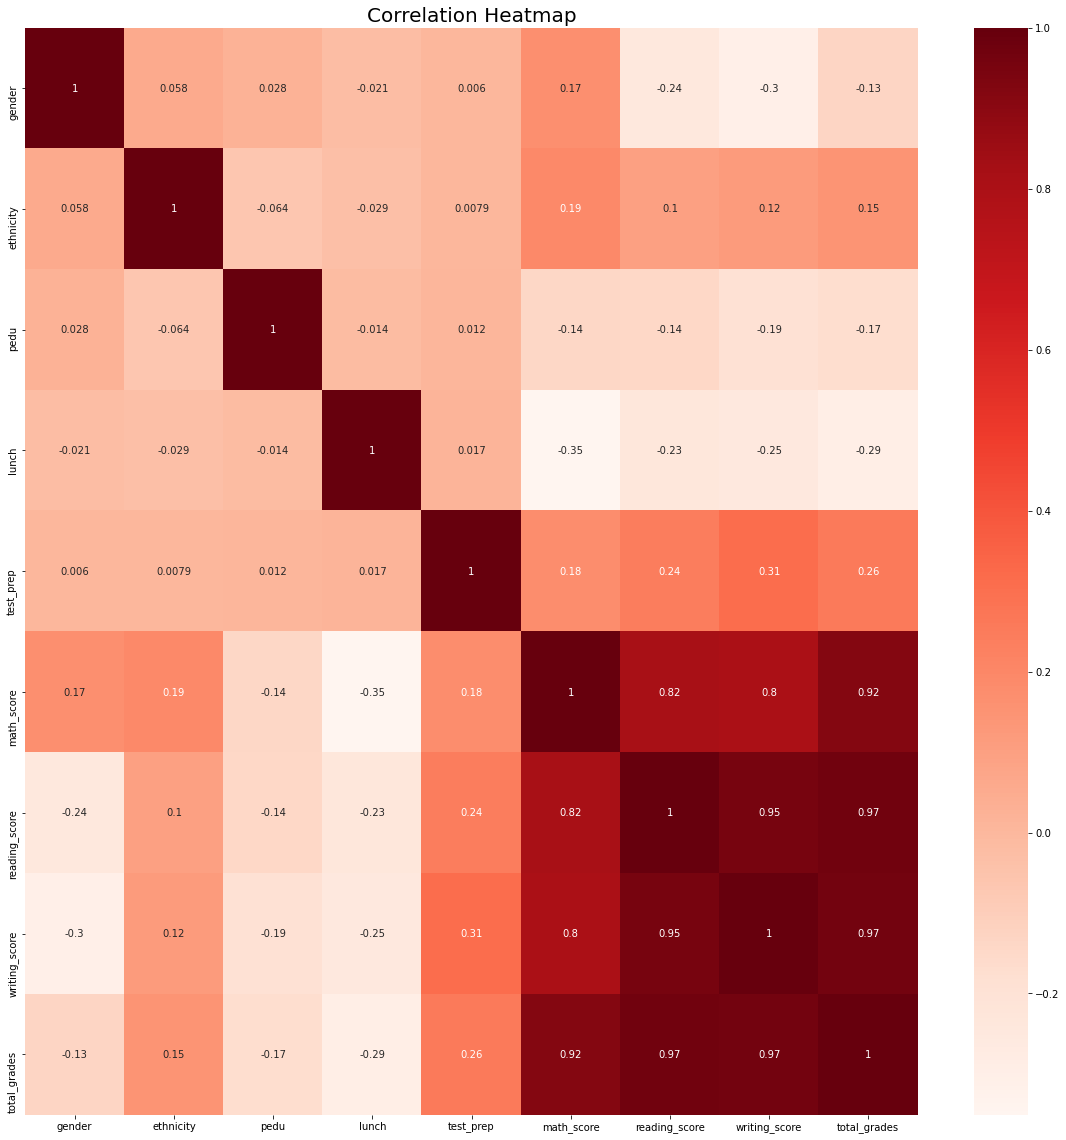

In [23]:
#describing correlation
corr=data.corr()

plt.figure(figsize=(20,20))
sns.heatmap(corr, annot=True, cmap="Reds")
plt.title('Correlation Heatmap', fontsize=20)

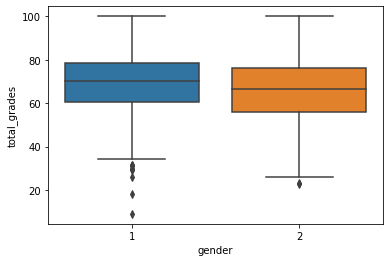

In [24]:
#comparing sex with grades
sns.boxplot(x="gender", y="total_grades", data=data)
school_counts=data["gender"].value_counts()
#as the graph of sex nearly overlaps so it will not have impact on grades
#stu=stu.drop(["sex"],axis=1)

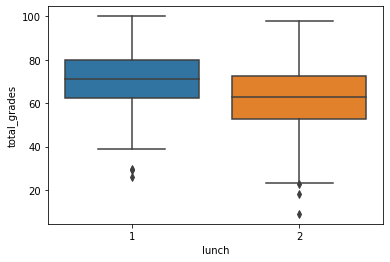

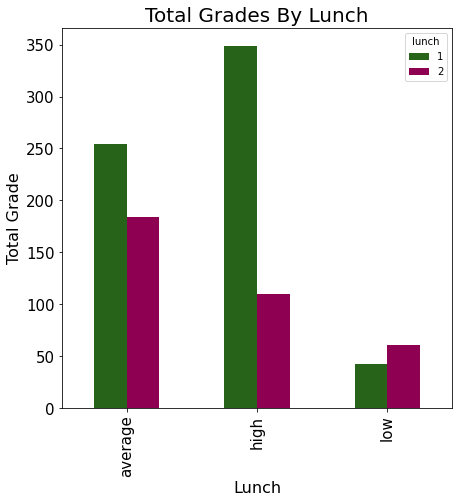

In [25]:
#comparing address with grades
sns.boxplot(x="lunch", y="total_grades", data=data)
index=["average","high","low"]

tab1 = pd.crosstab(columns=data.lunch, index=data.grades)

#address_perc=addresstab1.apply(perc).reindex(index)

tab1.plot.bar(colormap="PiYG_r", fontsize=15, figsize=(7,7))
plt.title('Total Grades By Lunch', fontsize=20)
plt.ylabel('Total Grade', fontsize=16)
plt.xlabel('Lunch', fontsize=16)
plt.show()
#address is factor for the grades

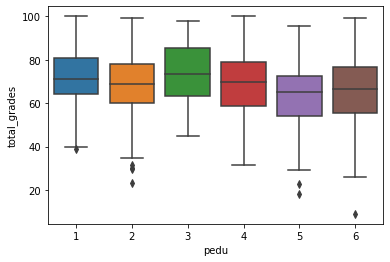

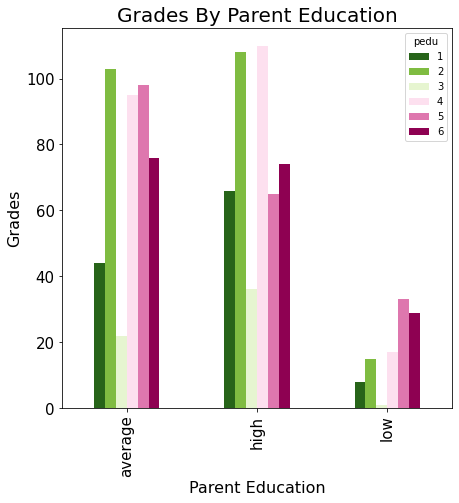

In [26]:
#comparing address with grades
sns.boxplot(x="pedu", y="total_grades", data=data)
index=["average","high","low"]

tab1 = pd.crosstab(columns=data.pedu, index=data.grades)

#address_perc=addresstab1.apply(perc).reindex(index)

tab1.plot.bar(colormap="PiYG_r", fontsize=15, figsize=(7,7))
plt.title('Grades By Parent Education', fontsize=20)
plt.ylabel('Grades', fontsize=16)
plt.xlabel('Parent Education', fontsize=16)
plt.show()
#address is factor for the grades

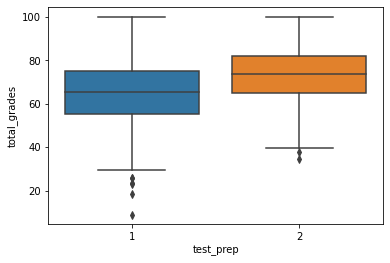

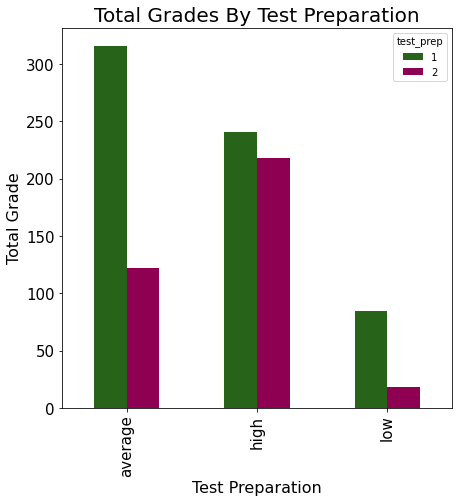

In [27]:
#comparing address with grades
sns.boxplot(x="test_prep", y="total_grades", data=data)
index=["average","high","low"]

tab1 = pd.crosstab(columns=data.test_prep, index=data.grades)

#address_perc=addresstab1.apply(perc).reindex(index)

tab1.plot.bar(colormap="PiYG_r", fontsize=15, figsize=(7,7))
plt.title('Total Grades By Test Preparation', fontsize=20)
plt.ylabel('Total Grade', fontsize=16)
plt.xlabel('Test Preparation', fontsize=16)
plt.show()
#address is factor for the grades

In [28]:
data

,gender,ethnicity,pedu,lunch,test_prep,math_score,reading_score,writing_score,total_grades,grades
0,1,1,1,1,1,72,72,74,72.666667,high
1,1,2,2,1,2,69,90,88,82.333333,high
2,1,1,3,1,1,90,95,93,92.666667,high
3,2,3,4,2,1,47,57,44,49.333333,low
4,2,2,2,1,1,76,78,75,76.333333,high
...,...,...,...,...,...,...,...,...,...,...
995,1,5,3,1,2,88,99,95,94.000000,high
996,2,2,5,2,1,62,55,55,57.333333,average
997,1,2,5,2,2,59,71,65,65.000000,average
998,1,4,2,1,2,68,78,77,74.333333,high


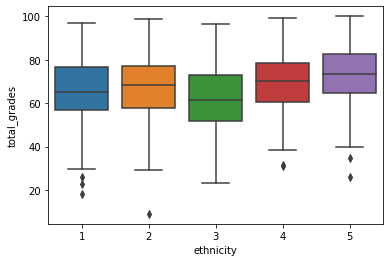

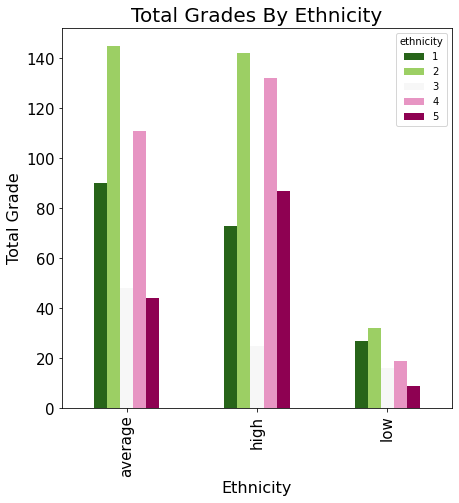

In [29]:
#comparing address with grades
sns.boxplot(x="ethnicity", y="total_grades", data=data)
index=["average","high","low"]

tab1 = pd.crosstab(columns=data.ethnicity, index=data.grades)

#address_perc=addresstab1.apply(perc).reindex(index)

tab1.plot.bar(colormap="PiYG_r", fontsize=15, figsize=(7,7))
plt.title('Total Grades By Ethnicity', fontsize=20)
plt.ylabel('Total Grade', fontsize=16)
plt.xlabel('Ethnicity', fontsize=16)
plt.show()
#address is factor for the grades

In [30]:
data_none = data

In [31]:
data_none

,gender,ethnicity,pedu,lunch,test_prep,math_score,reading_score,writing_score,total_grades,grades
0,1,1,1,1,1,72,72,74,72.666667,high
1,1,2,2,1,2,69,90,88,82.333333,high
2,1,1,3,1,1,90,95,93,92.666667,high
3,2,3,4,2,1,47,57,44,49.333333,low
4,2,2,2,1,1,76,78,75,76.333333,high
...,...,...,...,...,...,...,...,...,...,...
995,1,5,3,1,2,88,99,95,94.000000,high
996,2,2,5,2,1,62,55,55,57.333333,average
997,1,2,5,2,2,59,71,65,65.000000,average
998,1,4,2,1,2,68,78,77,74.333333,high


In [32]:
data1 = data

#data.grades = pd.factorize(data.grades)[0] + 1



In [33]:
data_none

,gender,ethnicity,pedu,lunch,test_prep,math_score,reading_score,writing_score,total_grades,grades
0,1,1,1,1,1,72,72,74,72.666667,high
1,1,2,2,1,2,69,90,88,82.333333,high
2,1,1,3,1,1,90,95,93,92.666667,high
3,2,3,4,2,1,47,57,44,49.333333,low
4,2,2,2,1,1,76,78,75,76.333333,high
...,...,...,...,...,...,...,...,...,...,...
995,1,5,3,1,2,88,99,95,94.000000,high
996,2,2,5,2,1,62,55,55,57.333333,average
997,1,2,5,2,2,59,71,65,65.000000,average
998,1,4,2,1,2,68,78,77,74.333333,high


In [34]:
#visualizing the grades
#plt.figure(figsize=(8,6))
#sns.countplot(data["grades"], order=[1,2,3], palette='Set1')
#plt.title('Final Grade against Number of Students',fontsize=20)
#plt.xlabel('Final Grade', fontsize=16)
#plt.ylabel('Number of Student', fontsize=16)

In [35]:
data1

,gender,ethnicity,pedu,lunch,test_prep,math_score,reading_score,writing_score,total_grades,grades
0,1,1,1,1,1,72,72,74,72.666667,high
1,1,2,2,1,2,69,90,88,82.333333,high
2,1,1,3,1,1,90,95,93,92.666667,high
3,2,3,4,2,1,47,57,44,49.333333,low
4,2,2,2,1,1,76,78,75,76.333333,high
...,...,...,...,...,...,...,...,...,...,...
995,1,5,3,1,2,88,99,95,94.000000,high
996,2,2,5,2,1,62,55,55,57.333333,average
997,1,2,5,2,2,59,71,65,65.000000,average
998,1,4,2,1,2,68,78,77,74.333333,high


<AxesSubplot:xlabel='ethnicity', ylabel='total_grades'>

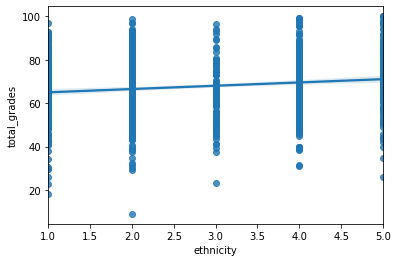

In [36]:
from scipy import stats
#comparing age with marks
sns.regplot(x="ethnicity",y="total_grades",data=data1)

In [37]:
#pearson coeffiecient
data1[["test_prep","total_grades"]].corr()
#p-value
pearson_coef , p_value=stats.pearsonr(data["test_prep"],data["total_grades"])

print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P =", p_value)
#parent education is not a good factor

The Pearson Correlation Coefficient is 0.2567097066562225  with a P-value of P = 1.6337802035923295e-16


In [38]:
#pearson coeffiecient
data1[["lunch","total_grades"]].corr()
#p-value
pearson_coef , p_value=stats.pearsonr(data["lunch"],data["total_grades"])

print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P =", p_value)
#lunch is not a good factor

The Pearson Correlation Coefficient is -0.2900640218711875  with a P-value of P = 7.736791812496049e-21


In [39]:
#pearson coeffiecient
data1[["gender","total_grades"]].corr()
#p-value
pearson_coef , p_value=stats.pearsonr(data["gender"],data["total_grades"])

print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P =", p_value)
#lunch is not a good factor

The Pearson Correlation Coefficient is -0.13086122988485363  with a P-value of P = 3.31197363824376e-05


In [40]:
#pearson coeffiecient
data1[["ethnicity","total_grades"]].corr()
#p-value
pearson_coef , p_value=stats.pearsonr(data["ethnicity"],data["total_grades"])

print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P =", p_value)
#lunch is not a good factor

The Pearson Correlation Coefficient is 0.14562879532328354  with a P-value of P = 3.7622979016724585e-06


In [41]:
#pearson coeffiecient
data1[["pedu","total_grades"]].corr()
#p-value
pearson_coef , p_value=stats.pearsonr(data["pedu"],data["total_grades"])

print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P =", p_value)
#lunch is not a good factor

The Pearson Correlation Coefficient is -0.16665209338247639  with a P-value of P = 1.1547389600909352e-07


In [42]:
data.describe()

,gender,ethnicity,pedu,lunch,test_prep,math_score,reading_score,writing_score,total_grades
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,1.482000,2.843000,3.689000,1.355000,1.358000,66.08900,69.169000,68.054000,67.770667
std,0.499926,1.370485,1.686156,0.478753,0.479652,15.16308,14.600192,15.195657,14.257326
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.00000,17.000000,10.000000,9.000000
25%,1.000000,2.000000,2.000000,1.000000,1.000000,57.00000,59.000000,57.750000,58.333333
50%,1.000000,2.000000,4.000000,1.000000,1.000000,66.00000,70.000000,69.000000,68.333333
75%,2.000000,4.000000,5.000000,2.000000,2.000000,77.00000,79.000000,79.000000,77.666667
max,2.000000,5.000000,6.000000,2.000000,2.000000,100.00000,100.000000,100.000000,100.000000


In [43]:
data.columns

Index(['gender', 'ethnicity', 'pedu', 'lunch', 'test_prep', 'math_score',
       'reading_score', 'writing_score', 'total_grades', 'grades'],
      dtype='object')

In [44]:
data3 = data_none.drop([ 'writing_score', 'total_grades', 'grades'], axis=1)

data4 = data_none.drop(['gender', 'ethnicity', 'pedu', 'lunch', 'test_prep', 'math_score', 'reading_score', 'writing_score', 'total_grades'], axis=1)

data5 = data_none.drop(['gender', 'ethnicity', 'pedu', 'lunch', 'test_prep', 'math_score', 'reading_score', 'writing_score', 'total_grades'], axis=1)

In [45]:
data4

,grades
0,high
1,high
2,high
3,low
4,high
...,...
995,high
996,average
997,average
998,high


In [46]:
np1=[1 for i in range(0, 1000)]
data5.insert(loc=0, column= "noimprotance", value=np1)

In [47]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data3, data4, test_size = 0.2, random_state = 0)

In [48]:
X_train

,gender,ethnicity,pedu,lunch,test_prep,math_score,reading_score
687,2,4,4,2,1,77,78
500,1,4,3,1,1,74,79
332,2,5,4,1,2,62,56
979,1,2,4,1,1,91,95
817,2,4,1,2,2,61,70
...,...,...,...,...,...,...,...
835,1,2,5,1,2,60,64
192,1,1,6,1,1,62,64
629,1,2,6,1,2,44,51
559,2,4,6,1,1,73,66


In [49]:
y_train

,grades
687,high
500,high
332,average
979,high
817,average
...,...
835,average
192,average
629,average
559,average


C:\Users\Qwerty\AppData\Local\Temp/ipykernel_13532/2266744512.py:6: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  classifier.fit(X_train,y_train)


gender:0.02545847916209027
ethnicity:0.032264897212035216
pedu:0.03950379196131558
lunch:0.0212520993408551
test_prep:0.02026891791055316


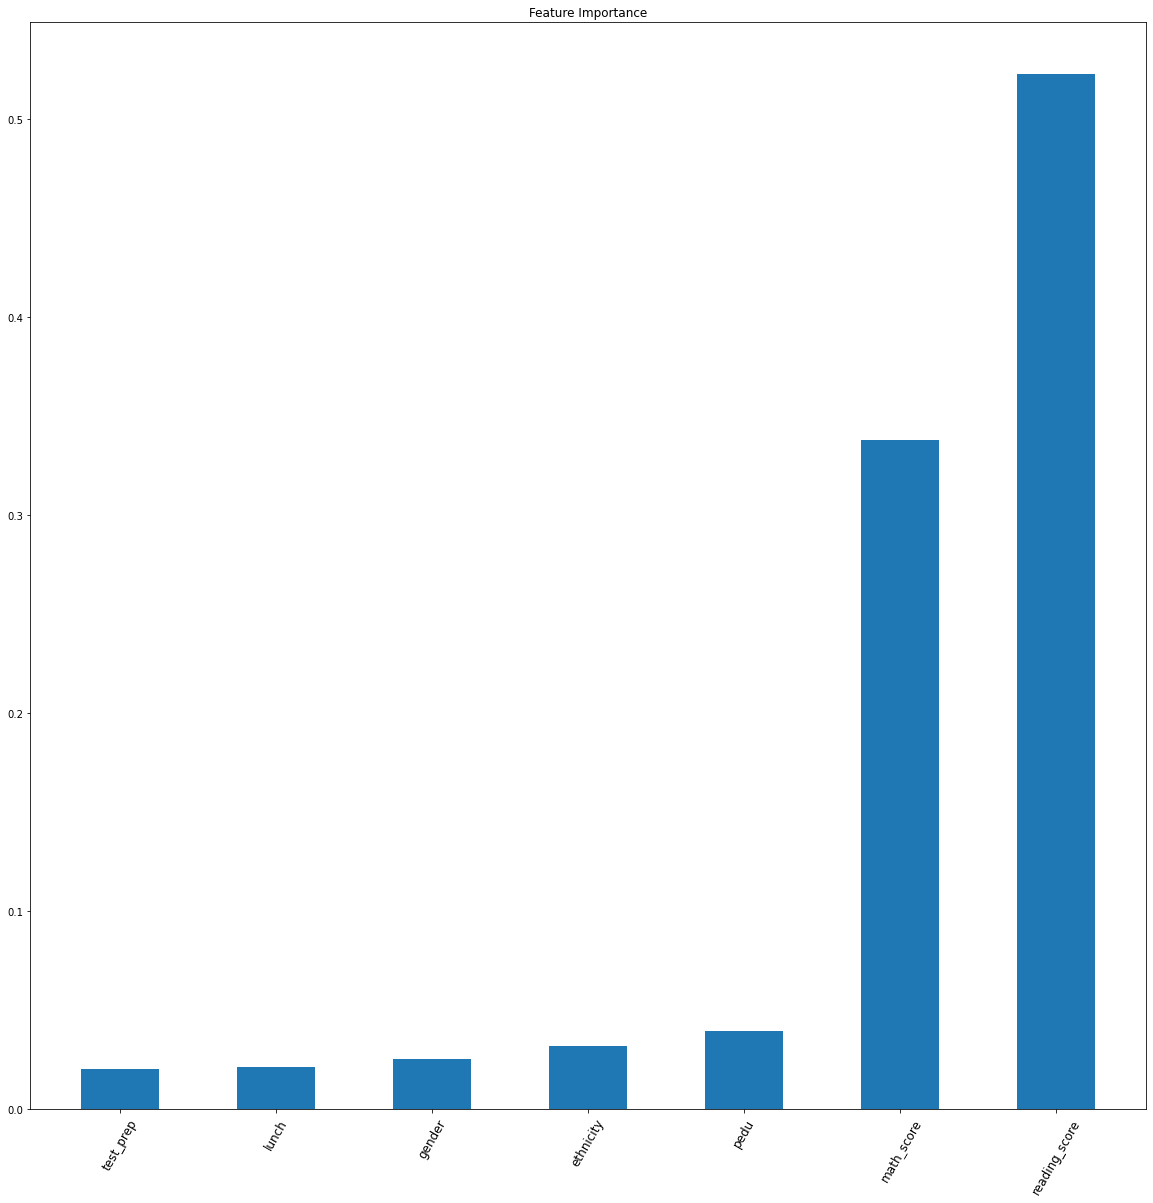

In [50]:
# =============================================================================
# #random forest
# =============================================================================
from sklearn.ensemble import RandomForestClassifier
classifier=RandomForestClassifier(n_estimators=80,criterion="entropy",random_state=0)
classifier.fit(X_train,y_train)

#predicting the test set re4sults
y_pred_random=classifier.predict(X_test)

importances=classifier.feature_importances_
for i,features in zip(importances,[ 
       'gender', 'ethnicity', 'pedu', 'lunch','test_prep']):
    print("{}:{}".format(features,i))
indices = np.argsort(importances)

# Rearrange feature names so they match the sorted feature importances
names = [data3.columns[i] for i in indices]

# Barplot: Add bars

plt.figure(figsize=(20,20))
plt.bar(range(data3.shape[1]), importances[indices],width=0.5)
# Add feature names as x-axis labels
plt.xticks(range(data3.shape[1]),names, rotation=60, fontsize = 12)
#from here we cam see that absences is the important features for determining the grades of students

# Create plot title
plt.title("Feature Importance")
# Show plot
plt.show()

#determinnig the confusion matrix
from sklearn.metrics import confusion_matrix
cm_random=confusion_matrix(y_test, y_pred_random)

#determining the precision,recall and f1-score 
from sklearn.metrics import classification_report
report_random=classification_report(y_test, y_pred_random)


In [51]:
names

['test_prep',
 'lunch',
 'gender',
 'ethnicity',
 'pedu',
 'math_score',
 'reading_score']

In [52]:
# =============================================================================
# # Fitting Kernel SVM to the Training set
# =============================================================================
from sklearn.svm import SVC
classifier = SVC(kernel = 'rbf', random_state = 0)
classifier.fit(X_train, y_train)
# Predicting the Test set results
y_pred_SVC= classifier.predict(X_test)
cm_SVC=confusion_matrix(y_test,y_pred_SVC)

#determining the precision,recall and f1-score 
from sklearn.metrics import classification_report
report_SVC=classification_report(y_test,y_pred_SVC)
print(report_SVC)

              precision    recall  f1-score   support

     average       0.93      0.97      0.95        95
        high       0.96      0.94      0.95        86
         low       1.00      0.89      0.94        19

    accuracy                           0.95       200
   macro avg       0.96      0.94      0.95       200
weighted avg       0.95      0.95      0.95       200



C:\Users\Qwerty\anaconda3\lib\site-packages\sklearn\utils\validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [53]:
# =============================================================================
# #fitting logistic regression to the training set
# =============================================================================
from sklearn.linear_model import LogisticRegression
classifier=LogisticRegression(random_state=0)
classifier.fit(X_train,y_train)
# Predicting the Test set results
y_pred_logistic= classifier.predict(X_test)

# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm_logistic= confusion_matrix(y_test, y_pred_logistic)

#determining the precision,recall and f1-score 
from sklearn.metrics import classification_report
report_logistic=classification_report(y_test,y_pred_logistic)

C:\Users\Qwerty\anaconda3\lib\site-packages\sklearn\utils\validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Qwerty\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [54]:
# =============================================================================
# #fitting the knn_calssifier to the training set
# =============================================================================
from sklearn.neighbors import KNeighborsClassifier
classifier=KNeighborsClassifier(n_neighbors=5,metric='minkowski',p=2)
classifier.fit(X_train,y_train)
# Predicting the Test set results
y_pred_knn= classifier.predict(X_test)

# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm_knn= confusion_matrix(y_test, y_pred_knn)

#determining the precision,recall and f1-score 
from sklearn.metrics import classification_report
report_knn=classification_report(y_test,y_pred_knn)

C:\Users\Qwerty\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:198: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [ ]:
print(report_random)
print(report_SVC)
print(report_logistic)
print(report_knn)